In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np


In [2]:
df = pd.read_csv("pca-1.csv")

START
Before cleaning: (375, 25)
After cleaning: (375, 25)
PCA result shape: (375, 2)


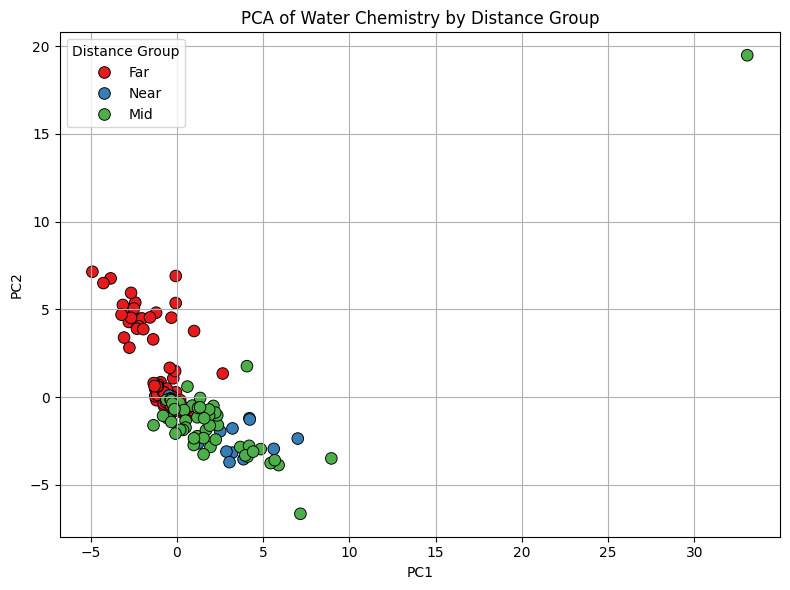

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("START")

df = pd.read_csv("pca-1.csv")

# ---------------------------
# STEP 1: Select numeric data
# ---------------------------
X = df.select_dtypes(include=['float64', 'int64'])

# REMOVE non-chemical columns (IMPORTANT)
exclude_cols = ["Year"]
X = X.drop(columns=exclude_cols, errors='ignore')

print("Before cleaning:", X.shape)

# ---------------------------
# STEP 2: Clean data
# ---------------------------

# remove useless columns (constant values)
X = X.loc[:, X.nunique() > 1]

# fill missing values (median is better)
X = X.fillna(X.median())

print("After cleaning:", X.shape)

# ---------------------------
# STEP 3: Standardize
# ---------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------
# STEP 4: PCA
# ---------------------------
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

print("PCA result shape:", pcs.shape)

# ---------------------------
# STEP 5: Plot (clean + legend)
# ---------------------------
labels = df['Distance Group']

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pcs[:,0],
    y=pcs[:,1],
    hue=labels,
    palette="Set1",
    s=70,          # bigger points
    edgecolor="black"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Water Chemistry by Distance Group")

plt.legend(title="Distance Group")
plt.grid(True)

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("START")

df = pd.read_csv("pca-1.csv")

# Only numeric data
X = df.select_dtypes(include=['float64', 'int64'])

print("Before cleaning:", X.shape)

# Fill missing values ONLY (no dropping)
X = X.fillna(X.mean())

print("After cleaning:", X.shape)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

print("PCA result shape:", pcs.shape)
print(pcs[:5])

START
Before cleaning: (375, 26)
After cleaning: (375, 26)
PCA result shape: (375, 2)
[[-0.02051826  0.00727031]
 [-0.04568902 -0.04695658]
 [ 0.28440254 -0.26167321]
 [-0.12184776  0.11032142]
 [ 0.08693753 -0.10738402]]


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Site Name                       375 non-null    object 
 1   Sampling Date                   375 non-null    object 
 2   Distance Group                  375 non-null    object 
 3   Aluminum Dissolved              76 non-null     float64
 4   Aluminum Total Recoverable      83 non-null     float64
 5   Calcium Dissolved               267 non-null    float64
 6   Calcium Total                   76 non-null     float64
 7   Copper Dissolved                76 non-null     float64
 8   Copper Total Recoverable        83 non-null     float64
 9   Lead Dissolved                  76 non-null     float64
 10  Lead Total Recoverable          83 non-null     float64
 11  Mercury Dissolved               46 non-null     float64
 12  Mercury Total                   76 n

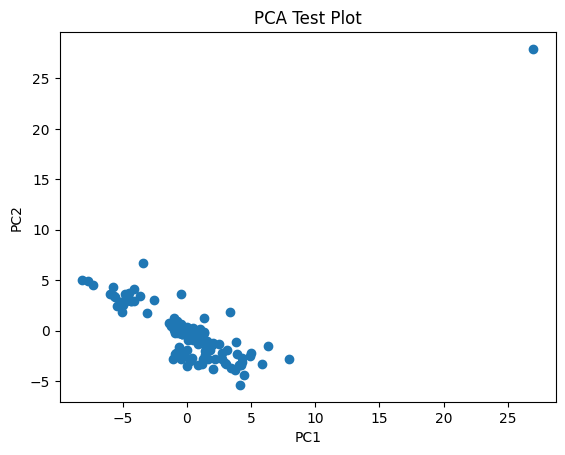

In [5]:
import matplotlib.pyplot as plt

plt.scatter(pcs[:,0], pcs[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Test Plot")
plt.show()

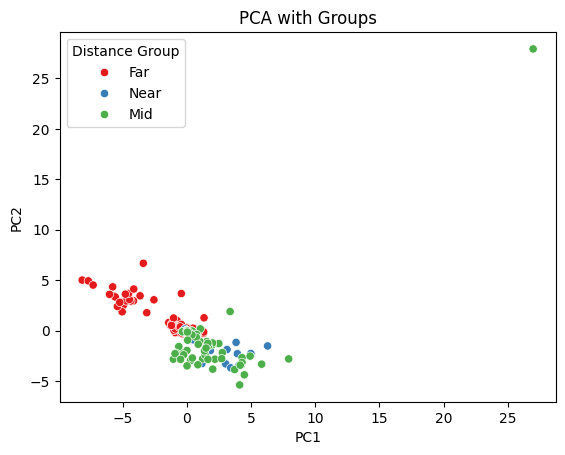

In [23]:
labels = df['Distance Group']
import seaborn as sns

sns.scatterplot(
    x=pcs[:,0],
    y=pcs[:,1],
    hue=labels,
    palette="Set1"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA with Groups")

plt.show()

In [26]:
print("Variables used in PCA:")
list(X.columns)

Variables used in PCA:


['Aluminum Dissolved',
 'Aluminum Total Recoverable',
 'Calcium Dissolved',
 'Calcium Total',
 'Copper Dissolved',
 'Copper Total Recoverable',
 'Lead Dissolved',
 'Lead Total Recoverable',
 'Mercury Dissolved',
 'Mercury Total',
 'Methyl Mercury',
 'Nickel Dissolved',
 'Nickel Total Recoverable',
 'Nitrogen Kjeldahl Dissolved',
 'Nitrogen Kjeldahl Total',
 'pH',
 'pH (Field)',
 'Phosphorus Total',
 'Phosphorus Total Dissolved',
 'Turbidity',
 'Vanadium Total Recoverable',
 'Vanadium Dissolved',
 'OXYGEN BIOCHEMICAL DEMAND',
 'Oxygen Dissolved (Field Meter)',
 'Oxygen dissolved % saturation']

In [16]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=X.columns
)

print(loadings)

                                     PC1       PC2
Aluminum Dissolved              0.183299  0.052735
Aluminum Total Recoverable      0.110874 -0.020922
Calcium Dissolved               0.234951 -0.139708
Calcium Total                   0.218421 -0.127165
Copper Dissolved                0.260241  0.379741
Copper Total Recoverable        0.261949  0.382500
Lead Dissolved                  0.293483  0.349350
Lead Total Recoverable          0.235491  0.330684
Mercury Dissolved              -0.056978 -0.018244
Mercury Total                   0.200007  0.096817
Methyl Mercury                  0.097643 -0.108403
Nickel Dissolved               -0.236029  0.331169
Nickel Total Recoverable       -0.146523  0.344320
Nitrogen Kjeldahl Dissolved     0.161453 -0.161591
Nitrogen Kjeldahl Total         0.321474 -0.020129
pH                              0.145663 -0.160594
pH (Field)                      0.131430 -0.138544
Phosphorus Total                0.027275 -0.024688
Phosphorus Total Dissolved     

In [17]:
print(loadings["PC1"].sort_values(ascending=False))
print(loadings["PC2"].sort_values(ascending=False))

Vanadium Dissolved                0.355811
Nitrogen Kjeldahl Total           0.321474
Lead Dissolved                    0.293483
Vanadium Total Recoverable        0.282556
Copper Total Recoverable          0.261949
Copper Dissolved                  0.260241
Lead Total Recoverable            0.235491
Calcium Dissolved                 0.234951
Calcium Total                     0.218421
Mercury Total                     0.200007
Aluminum Dissolved                0.183299
Turbidity                         0.164354
Nitrogen Kjeldahl Dissolved       0.161453
pH                                0.145663
pH (Field)                        0.131430
Oxygen dissolved % saturation     0.114016
Aluminum Total Recoverable        0.110874
Methyl Mercury                    0.097643
OXYGEN BIOCHEMICAL DEMAND         0.032059
Phosphorus Total                  0.027275
Year                              0.001568
Phosphorus Total Dissolved        0.000785
Mercury Dissolved                -0.056978
Nickel Tota

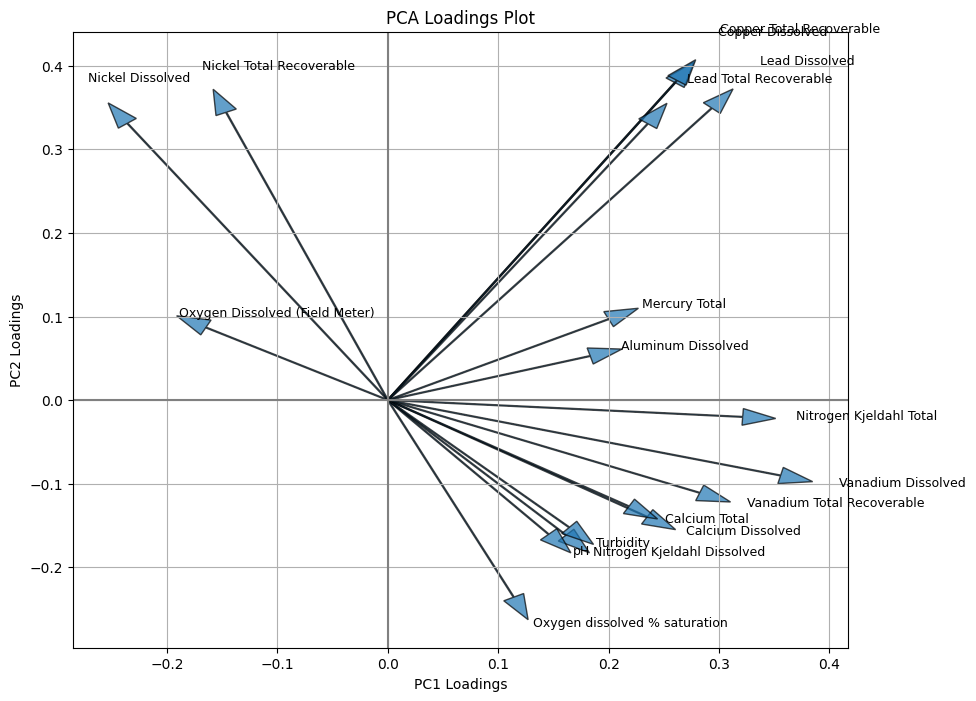

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

threshold = 0.15  

for i, var_name in enumerate(loadings.index):
    x = loadings.iloc[i, 0]  # PC1
    y = loadings.iloc[i, 1]  # PC2

    if abs(x) > threshold or abs(y) > threshold:
        plt.arrow(0, 0, x, y, alpha=0.7, head_width=0.02)
        plt.text(x*1.15, y*1.15, var_name, fontsize=9)

plt.axhline(0, color='gray')
plt.axvline(0, color='gray')

plt.xlabel("PC1 Loadings")
plt.ylabel("PC2 Loadings")
plt.title("PCA Loadings Plot")

plt.grid(True)
plt.show()

In [21]:
import pandas as pd
import numpy as np

explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

variance_df = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(explained_var))],
    "Variance Explained (%)": explained_var * 100,
    "Cumulative Variance (%)": cum_var * 100
})

print(variance_df)

  Principal Component  Variance Explained (%)  Cumulative Variance (%)
0                 PC1               19.370215                19.370215
1                 PC2               15.375614                34.745830
